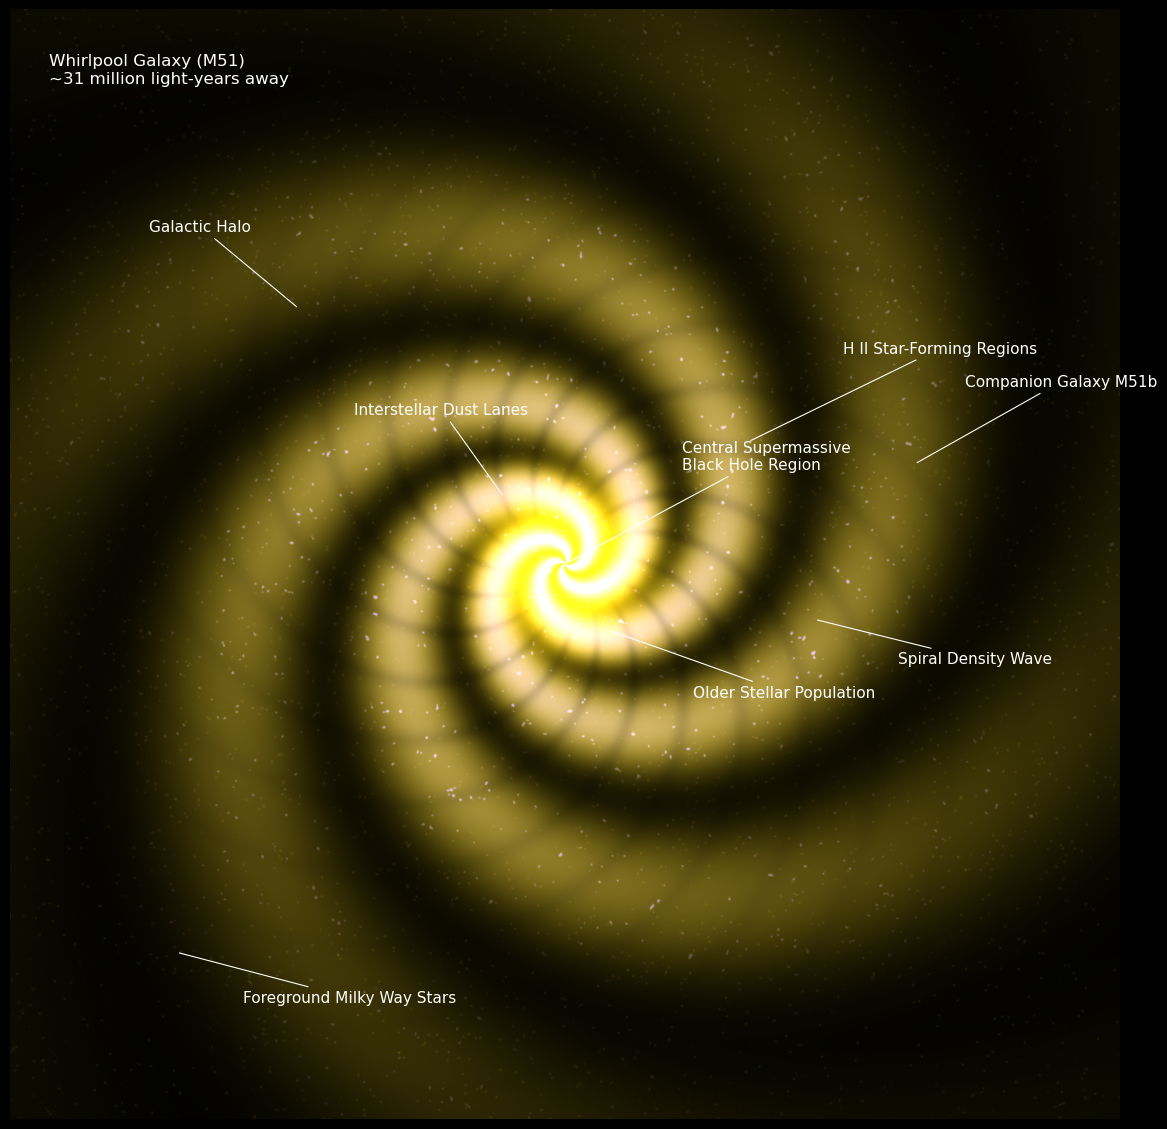

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ----------------------------
# Canvas
# ----------------------------
size = 2000
x = np.linspace(-3, 3, size)
y = np.linspace(-3, 3, size)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

# ----------------------------
# Spiral Arms
# ----------------------------
arms = np.zeros_like(R)

for offset in [0, np.pi]:
    spiral = np.cos(2 * Theta - 5 * np.log(R + 0.2) + offset)
    arm_strength = np.exp(-R * 0.9) * ((spiral + 1) / 2) ** 4
    arms += arm_strength

# ----------------------------
# Core
# ----------------------------
core = 1.8 * np.exp(-(R**2) / 0.12)
core_texture = gaussian_filter(np.random.random((size, size)), sigma=6)
core *= (0.7 + 0.3 * core_texture)

# ----------------------------
# Dust Lanes
# ----------------------------
dust = 1 - 0.6 * np.exp(-((np.sin(8 * Theta + R * 7))**2) / 0.25) * np.exp(-R)

# ----------------------------
# Blue Star Forming Regions
# ----------------------------
stars_blue = np.random.random((size, size))
stars_blue = gaussian_filter(stars_blue, sigma=2)
stars_blue = (stars_blue > 0.6).astype(float)
stars_blue *= arms * 1.8

# ----------------------------
# Background Stars
# ----------------------------
bg = np.random.random((size, size))
bg = (bg > 0.9995).astype(float)
bg = gaussian_filter(bg, sigma=1)

# ----------------------------
# Final Image
# ----------------------------
img = (arms * dust * 2.0) + core + stars_blue + bg
img = gaussian_filter(img, sigma=1.1)
img = np.tanh(img * 1.2)
img = img / img.max()

rgb = np.zeros((size, size, 3))
rgb[:, :, 0] = img * 1.1 + core * 0.4
rgb[:, :, 1] = img * 0.95 + core * 0.3
rgb[:, :, 2] = img * 1.3 * arms + stars_blue * 1.5
rgb = np.clip(rgb, 0, 1)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 12), facecolor='black')
ax.imshow(rgb, origin='lower')
ax.axis('off')

# ----------------------------
# Label Helper
# ----------------------------
def label(text, xy, xytext):
    ax.annotate(
        text,
        xy=xy,
        xytext=xytext,
        color='white',
        fontsize=11,
        arrowprops=dict(arrowstyle='-', lw=0.8, color='white')
    )

# ----------------------------
# Real / Known Whirlpool Galaxy Features
# ----------------------------

# Main nucleus
label("Central Supermassive\nBlack Hole Region", (1000, 1000), (1210, 1170))

# Spiral density wave
label("Spiral Density Wave", (1450, 900), (1600, 820))

# Dust lanes
label("Interstellar Dust Lanes", (890, 1120), (620, 1270))

# Star forming nebulae
label("H II Star-Forming Regions", (1330, 1220), (1500, 1380))

# Older yellow stars
label("Older Stellar Population", (1080, 880), (1230, 760))

# Halo
label("Galactic Halo", (520, 1460), (250, 1600))

# Companion galaxy position
label("Companion Galaxy M51b", (1630, 1180), (1720, 1320))

# Foreground stars
label("Foreground Milky Way Stars", (300, 300), (420, 210))

# Distance note
ax.text(
    70, 1920,
    "Whirlpool Galaxy (M51)\n~31 million light-years away",
    color='white',
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
plt.show()